In [15]:

# ==============================
# 1️⃣ Import Required Libraries
# ==============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.models import load_model

In [16]:
# ==============================
# 2️⃣ Define Dataset Paths
# ==============================

# Update these paths to your dataset directories
train_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train'
valid_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation'
test_path  = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test'

BATCH_SIZE = 16  # Recommended for medical dataset
IMG_SIZE = (224, 224)

In [17]:
# ==============================
# 3️⃣ Data Preprocessing
# ==============================

# EfficientNet requires its own preprocessing function
def tl_preprocess(x):
    return preprocess_input(x)

# Create ImageDataGenerators for train, validation, and test
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_valid_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_test_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

# Load images from directories
tl_train_generator = tl_train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_valid_generator = tl_valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_test_generator = tl_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 57832 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.


In [4]:
# ==============================
# 4️⃣ Load Pretrained EfficientNetB0
# ==============================

# Load EfficientNetB0 pretrained on ImageNet
base_model = EfficientNetB0(
    weights='imagenet',       # Use pretrained ImageNet weights
    include_top=False,        # Remove original classification head
    input_shape=(224,224,3)   # Input shape must match dataset
)

# Freeze the base model for feature extraction phase
base_model.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 29s 2us/step


In [18]:
# ==============================
# 5️⃣ Build Custom Classification Head
# ==============================

model = keras.Sequential([
    
    base_model,                              # Pretrained feature extractor
    
    keras.layers.GlobalAveragePooling2D(),   # Convert feature maps to vector
    
    keras.layers.BatchNormalization(),       # Stabilize training
    
    keras.layers.Dense(256, activation='relu'),  # Fully connected layer
    
    keras.layers.Dropout(0.5),               # Reduce overfitting
    
    keras.layers.Dense(4, activation='softmax')  # Output layer (4 classes)
])


In [6]:
# ==============================
# 6️⃣ Compile Model (Feature Extraction Phase)
# ==============================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Small learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
# ==============================
# 7️⃣ Callbacks (Professional Setup)
# ==============================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_efficientnet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]


In [10]:
# ==============================
# 8️⃣ Train (Feature Extraction)
# ==============================

history = model.fit(
    tl_train_generator,
    epochs=20,                    # EarlyStopping will stop automatically
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7683 - loss: 0.6415
Epoch 1: val_loss improved from inf to 0.21987, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1327s 367ms/step - accuracy: 0.7683 - loss: 0.6414 - val_accuracy: 0.9227 - val_loss: 0.2199 - learning_rate: 1.0000e-04
Epoch 2/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8884 - loss: 0.3138
Epoch 2: val_loss improved from 0.21987 to 0.17885, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1258s 348ms/step - accuracy: 0.8884 - loss: 0.3138 - val_accuracy: 0.9365 - val_loss: 0.1789 - learning_rate: 1.0000e-04
Epoch 3/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9052 - loss: 0.2652
Epoch 3: val_loss improved from 0.17885 to 0.16755, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1267s 350ms/step - accuracy: 0.9052 - loss: 0.2652 - val_accuracy: 0.9444 - val_loss: 0.1675 - learning_r

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model

# Step 1: Rebuild model
base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

inputs = layers.Input(shape=(224,224,3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

# Step 2: Load weights
model.load_weights("best_efficientnet_model.keras")

In [26]:
model.load_weights("best_efficientnet_model.keras")
print ("model_loaded")

model_loaded


In [21]:
# ==============================
# 9️⃣ Fine-Tuning Phase
# ==============================

# Unfreeze last 20 layers of EfficientNet
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again (fine-tuning)
fine_tune_history = model.fit(
    tl_train_generator,
    epochs=15,
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/15


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6280 - loss: 1.0508
Epoch 1: val_loss improved from inf to 0.30665, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1665s 458ms/step - accuracy: 0.6280 - loss: 1.0507 - val_accuracy: 0.8970 - val_loss: 0.3067 - learning_rate: 1.0000e-05
Epoch 2/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8355 - loss: 0.4677
Epoch 2: val_loss improved from 0.30665 to 0.23409, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1704s 471ms/step - accuracy: 0.8355 - loss: 0.4677 - val_accuracy: 0.9184 - val_loss: 0.2341 - learning_rate: 1.0000e-05
Epoch 3/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8673 - loss: 0.3746
Epoch 3: val_loss improved from 0.23409 to 0.19765, saving model to best_efficientnet_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 1741s 481ms/step - accuracy: 0.8673 - loss: 0.3746 - val_accuracy: 0.9314 - val_loss: 0.1976 - learning_rate: 1.0000

In [22]:
# ==============================
# 🔟 Evaluate Model
# ==============================

test_loss, test_accuracy = model.evaluate(tl_test_generator)

print("Test Accuracy:", test_accuracy)

452/452 ━━━━━━━━━━━━━━━━━━━━ 178s 394ms/step - accuracy: 0.9687 - loss: 0.0980
Test Accuracy: 0.9676437973976135


452/452 ━━━━━━━━━━━━━━━━━━━━ 155s 338ms/step


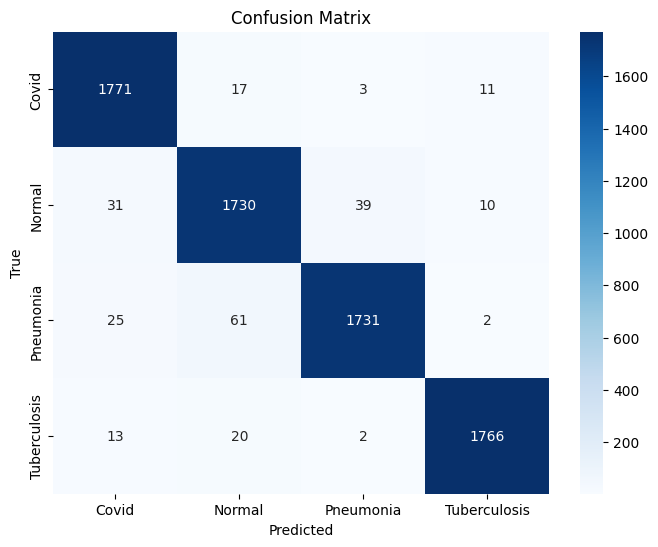

Classification Report:

              precision    recall  f1-score   support

       Covid       0.96      0.98      0.97      1802
      Normal       0.95      0.96      0.95      1810
   Pneumonia       0.98      0.95      0.96      1819
Tuberculosis       0.99      0.98      0.98      1801

    accuracy                           0.97      7232
   macro avg       0.97      0.97      0.97      7232
weighted avg       0.97      0.97      0.97      7232



In [23]:
# ==============================
# Confusion Matrix & Classification Report
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
Y_pred = model.predict(tl_test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = tl_test_generator.classes

# Class labels
class_labels = list(tl_test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

In [27]:
# ==============================
# Plot Training History
# ==============================

def plot_history(history):
    
    # Accuracy plot
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()
    
    # Loss plot
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history)

NameError: name 'history' is not defined

In [23]:
# ==============================
# Functional Model (Grad-CAM Safe)
# ==============================

from tensorflow.keras import layers, Model

# Base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Define input explicitly
inputs = layers.Input(shape=(224,224,3))

# Forward pass through EfficientNet
x = base_model(inputs, training=False)

# Custom head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

# Create model
model = Model(inputs, outputs)

In [24]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Get EfficientNet layer
    last_conv_layer = model.get_layer("efficientnetb0").get_layer(last_conv_layer_name)

    # Create grad model
    grad_model = Model(
        [model.input],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

img_path = "test.jpg"  # your image

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

# ✅ USE THIS (correct for EfficientNet)
img_array = preprocess_input(img_array)

In [ ]:
pred = model.predict(img_array)
print(pred)

In [25]:
img_path = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test\Covid\00f9707e0de334db70a7924a9de98368.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

heatmap = make_gradcam_heatmap(img_array, model, "top_conv")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m2918105922720\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[  0.,   0.,   0.],\n         [  3.,   3.,   3.],\n         [  4.,   4.,   4.],\n         ...,\n         [129., 129., 129.],\n         [157., 157., 157.],\n         [161., 161., 161.]],\n\n        [[  2.,   2.,   2.],\n         [  5.,   5.,   5.],\n         [  7.,   7.,   7.],\n         ...,\n         [117., 117., 117.],\n         [147., 147., 147.],\n         [173., 173., 173.]],\n\n        [[  4.,   4.,   4.],\n         [  7.,   7.,   7.],\n         [  8.,   8.,   8.],\n         ...,\n         [131., 131., 131.],\n         [140., 140., 140.],\n         [172., 172., 172.]],\n\n        ...,\n\n        [[  0.,   0.,   0.],\n         [  0.,   0.,   0.],\n         [  0.,   0.,   0.],\n         ...,\n         [251., 251., 251.],\n         [  0.,   0.,   0.],\n         [153., 153., 153.]],\n\n        [[  0.,   0.,   0.],\n         [

In [26]:
for layer in model.layers:
    print(layer.name)

input_layer_3
efficientnetb0
global_average_pooling2d_1
batch_normalization_1
dense_2
dropout_1
dense_3
